In [45]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv(r"C:\Users\This PC\Downloads\HousePricePrediction.csv")
df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [38]:
#preprocessing of data
# df.drop(["Id"],axis = 1,inplace = True)
df["SalePrice"]= df["SalePrice"].fillna(df["SalePrice"].mean())
df = df.dropna()

In [ ]:
#encoding
cols = ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
df = pd.get_dummies(df, columns=cols, drop_first=True)

In [41]:
x = df.drop("SalePrice",axis = 1)
y = df["SalePrice"]

In [42]:
#train-Test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 0)

In [43]:
lr = LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
# Model Evaluation
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,mean_absolute_percentage_error
y_pred = lr.predict(x_test)

print("r2 score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("MAPE:",mean_absolute_percentage_error(y_test,y_pred))

r2 score: 0.31875344530637173
MAE: 31520.85554040125
MSE: 43284.11082703144
MAPE: 0.18688742441065254


In [51]:
# Feature scaling - to try & improve baseline performance
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

model = LinearRegression()
model.fit(x_train_scaled,y_train)

y_pred = model.predict(x_test_scaled)

print("r2 score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("MAPE:",mean_absolute_percentage_error(y_test,y_pred))

r2 score: 0.31875344530637095
MAE: 31520.855540401393
MSE: 43284.110827031465
MAPE: 0.18688742441065184


In [56]:
# Bagging
from sklearn.ensemble import BaggingRegressor 
bagr = BaggingRegressor(lr,n_estimators = 100)
bagr.fit(x_train_scaled,y_train)
y_pred = bagr.predict(x_test_scaled)

print("r2 score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("MAPE:",mean_absolute_percentage_error(y_test,y_pred))

r2 score: 0.3181267992702089
MAE: 31558.640646280677
RMSE: 43304.01374006959
MAPE: 0.18715556634774055


mean_squared_error for 0.001:  1873504392.2350557
mean_squared_error for 0.01:  1873416350.761256
mean_squared_error for 0.5:  1869867384.0396347
mean_squared_error for 1:  1867559693.8241653
mean_squared_error for 2:  1864497592.8243535
mean_squared_error for 5:  1859921835.0503073
mean_squared_error for 10:  1858018120.7346523
mean_squared_error for 20:  1860178253.7594733
mean_squared_error for 40:  1866817311.0549715


<Axes: >

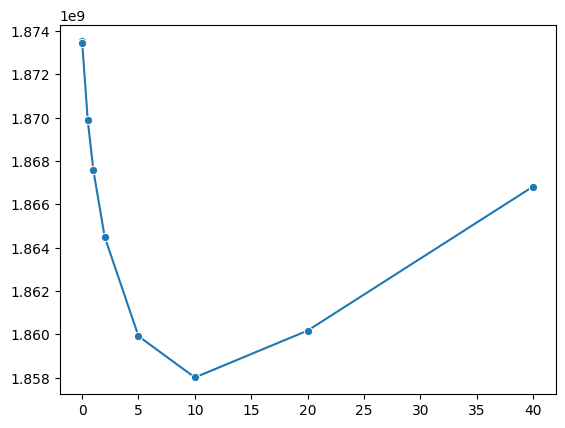

In [74]:
from sklearn.linear_model import Ridge,Lasso,LassoCV
alphas = [0.001,0.01,0.5,1,2,5,10,20,40]
ms = []
for a in alphas:
    lm = Ridge(alpha = a)
    lm.fit(x_train,y_train)
    y_pr = lm.predict(x_test)
    mse = mean_squared_error(y_test,y_pr)
    print(f"mean_squared_error for {a}: ",mse)
    ms.append(mse)
sns.lineplot(x= alphas,y= ms,marker = "o")

In [77]:
lasso_model = LassoCV(alphas = alphas,max_iter = 1000,cv = 5, random_state = 42)
lasso_model.fit(x_train,y_train)
print("best alpha:",lasso_model.alpha_)
y_p = lasso_model.predict(x_test)
mse = mean_squared_error(y_test,y_p)
r2 = r2_score(y_test,y_p)
print("mse:",mse)
print("r2:",r2)

best alpha: 40.0
mse: 1867695898.4751217
r2: 0.32086911215503744


<Axes: >

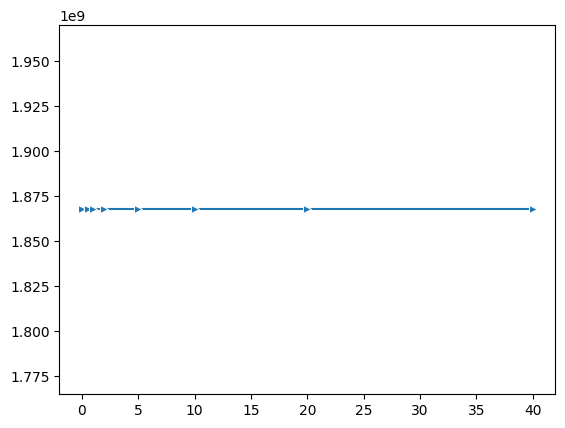

In [78]:
sns.lineplot(x= alphas,y= mse,marker=">")